# Assignment 1 - From Pixels to a Defensible Classifier
## Group 4: Weight Decay Regularisation

**STUDENT IN-CLASS EVIDENCE NOTEBOOK**

Coverage: **Weeks 1–4 - Images as Data, CNNs, Evaluation/Error Analysis, Transfer Learning**.

The objective is not to maximize accuracy. The objective is to produce a **valid, reproducible and evidence-based comparison**.

In [1]:
GROUP_NUMBER = 4
GROUP_NAME = 'Weight Decay Regularisation'
SEED = 42
BASELINE_EPOCHS = 12
BASELINE_SIZE = 96
print(GROUP_NUMBER, GROUP_NAME)

4 Weight Decay Regularisation


## 0. Locate the offline resources
The lecturer-provided resources include the dataset, group variant, utilities, and cached source-pretrained ResNet18.

In [2]:
from pathlib import Path
import os, sys, zipfile

def find_pack():
    candidates=[Path('/content/CV_DL_Assignment1_Practical_Pack'),Path.cwd()/ 'CV_DL_Assignment1_Practical_Pack',Path.cwd().parent/'CV_DL_Assignment1_Practical_Pack',Path.cwd(),Path.cwd().parent]
    for p in candidates:
        if (p/'utils'/'assignment_utils.py').exists() and (p/'resources').exists(): return p.resolve()
    return None
PACK=find_pack()
if PACK is None:
    try:
        from google.colab import files
        print('Upload CV_DL_Assignment1_Resources.zip supplied by the lecturer.')
        uploaded=files.upload(); zname=next((n for n in uploaded if n.lower().endswith('.zip')),None)
        if zname is None: raise RuntimeError('No ZIP uploaded')
        with zipfile.ZipFile(zname) as z: z.extractall('/content')
        PACK=find_pack()
    except Exception as e: raise RuntimeError('Practical resources not found.') from e
print('PACK =',PACK)
sys.path.insert(0,str(PACK/'utils'))
from assignment_utils import *
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from PIL import Image
seed_everything(SEED)
RES=PACK/'resources'; WEIGHTS=PACK/'weights'/'resnet18_source_pretrained.pth'; EVIDENCE=prepare_evidence(PACK,GROUP_NUMBER)
TRAIN_MANIFEST=RES/f'group{GROUP_NUMBER}_train_manifest.csv'; VAL_MANIFEST=RES/'common/val_manifest.csv'
print('Train manifest:',TRAIN_MANIFEST.name,'Validation:',VAL_MANIFEST.name,'Cached weights:',WEIGHTS.exists())

PACK = C:\Users\chari\Desktop\Week 1- 4 Prac group assignment\Week 1- 4 Prac group assignment
Train manifest: group4_train_manifest.csv Validation: val_manifest.csv Cached weights: True


# Part A - Understand the Data

Before training, inspect what the model will receive. The model cannot repair an invalid data contract or a misleading split.

Training images: 180
class_name
metal      60
paper      60
plastic    60
Name: count, dtype: int64

Validation images: 270
class_name
metal      90
paper      90
plastic    90
Name: count, dtype: int64


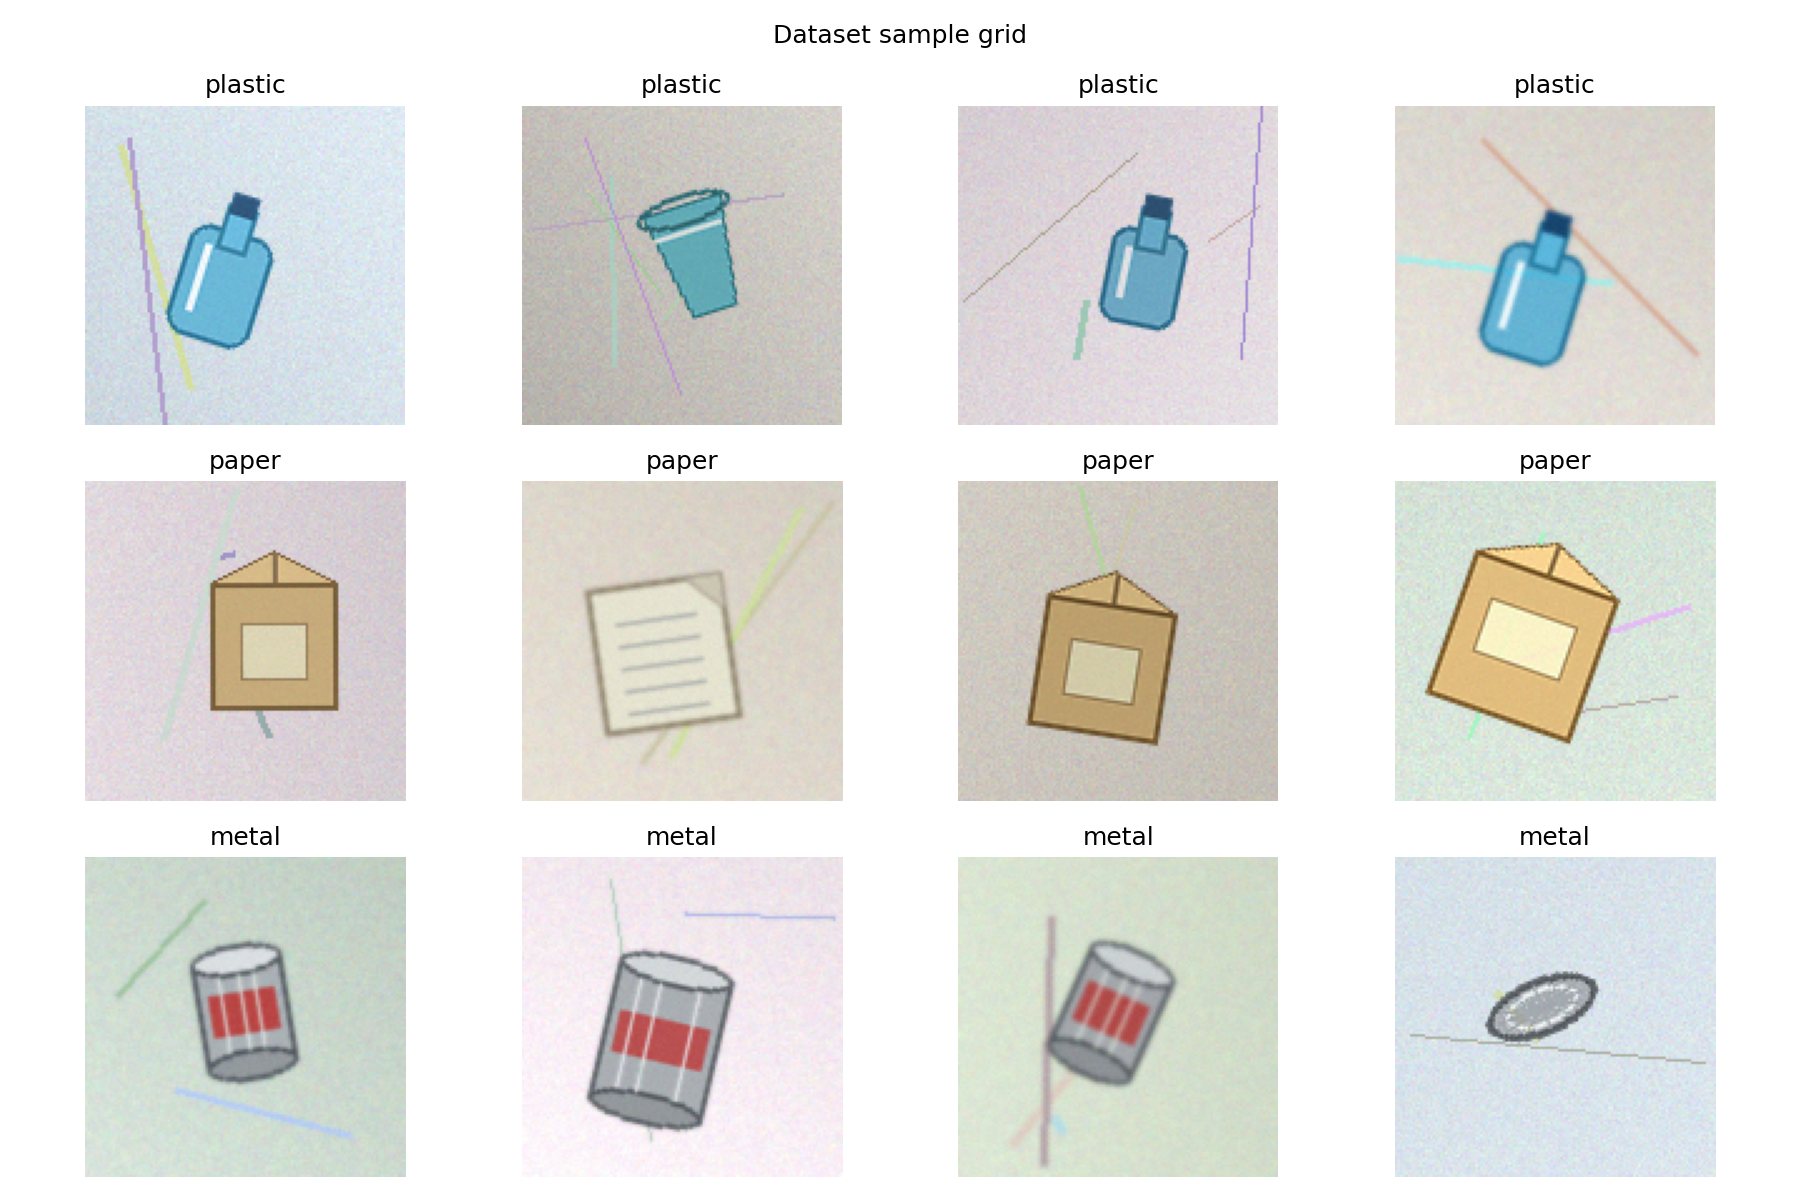


Example path: common/images/train/plastic/plastic_train_000.png
PIL size (W,H): (128, 128)
Array shape: (128, 128, 3)
dtype: uint8
range: 20 255


In [3]:
train_df=pd.read_csv(TRAIN_MANIFEST); val_df=pd.read_csv(VAL_MANIFEST)
print('Training images:',len(train_df)); print(train_df['class_name'].value_counts().sort_index())
print(); print('Validation images:',len(val_df)); print(val_df['class_name'].value_counts().sort_index())
plot_sample_grid(RES,TRAIN_MANIFEST,EVIDENCE/'dataset_sample_grid.png',n_per_class=4,seed=SEED)
display(Image.open(EVIDENCE/'dataset_sample_grid.png'))

r=train_df.iloc[0]; im=Image.open(RES/r.path).convert('RGB'); arr=np.asarray(im)
print(); print('Example path:',r.path); print('PIL size (W,H):',im.size); print('Array shape:',arr.shape); print('dtype:',arr.dtype); print('range:',arr.min(),arr.max())

### GROUP ANSWERS - Part A

1. **Input to the system:** Different material classes.
2. **Output classes:** plastic, paper, metal 
3. **Intended use:** Classifying an input image into one of the three material categories.
4. **One important non-use:** The dataset is explicitly a teaching dataset, not evidence of real-world waste-classification performance.
5. **Why classification rather than detection/segmentation?** Because the task is:What material class does this image belong to? and not:locate an object with a bounding box → detection
identify individual pixels belonging to the object → segmentation
We're assigning the image a class.  
6. **One observed data/evaluation risk:** illumination variation, visually similar classes, background correlation, object appearance variation

# Part B - Understand the CNN Before Running It

For input **3 × 96 × 96**, the baseline is:

`Conv(3→16, 3×3, pad=1) → ReLU → MaxPool(2) → Conv(16→32) → ReLU → MaxPool(2) → Conv(32→64) → ReLU → AdaptiveAvgPool(1×1) → Linear(64→3)`

**Predict first. Do not run the shape-check cell until your table is complete.**

Given that the batch size is 4

| Stage | Your predicted output shape | Rationale
|---|---|---|
| Input | 4 x 3 x 96 x 96 | RGB image (3 channels x W x H) |
| Conv1 | 4 x 16 x 96 x 96 | channels become 16, size kept(pad=1) |
| Pool1 | 4 x 16 x 48 x 48 | halve the H and W |
| Conv2 | 4 x 32 x 48 x 48 | channels become 32, size kept |
| Pool2 | 4 x 32 x 24 x 24 | halve the H and W |
| Conv3 | 4 x 64 x 24 x 24 | channels become 64, size kept |
| Adaptive Pool | 4 x 64 x 1 x 1 | each channels is averaged into 1 value |
| Linear | 4 x 3 | for each image in the batch it classifies them among 3 features |

**Parameter calculation for Conv1:** 

Parameters = (input_channels x kernel x kernel + 1) x output_channel/filters

input_channels = 3 , kernel = 3, output_channels/filters = 16

Parameters = (3 x 3 x 3 + 1) x 16 = 448 params

In [4]:
model=SmallCNN(3); x=torch.zeros(4,3,96,96)
print('input',tuple(x.shape))
for layer in model.features:
    x=layer(x); print(layer.__class__.__name__,tuple(x.shape))
x=x.flatten(1); print('flatten',tuple(x.shape)); print('output',tuple(model.classifier(x).shape))
print('Total trainable parameters:',count_trainable(model))

input (4, 3, 96, 96)
Conv2d (4, 16, 96, 96)
ReLU (4, 16, 96, 96)
MaxPool2d (4, 16, 48, 48)
Conv2d (4, 32, 48, 48)
ReLU (4, 32, 48, 48)
MaxPool2d (4, 32, 24, 24)
Conv2d (4, 64, 24, 24)
ReLU (4, 64, 24, 24)
AdaptiveAvgPool2d (4, 64, 1, 1)
flatten (4, 64)
output (4, 3)
Total trainable parameters: 23779


# Part C - Establish the Baseline
All group comparisons must preserve the fixed validation set. The intervention will change only the assigned major variable.

In [5]:
train_loader,val_loader,train_ds,val_ds=make_loaders(RES,TRAIN_MANIFEST,VAL_MANIFEST,size=BASELINE_SIZE,batch_size=64,augment=False,seed=SEED)
seed_everything(SEED); baseline_model=SmallCNN(3)
baseline_model,baseline_history,baseline_seconds=train_model(baseline_model,train_loader,val_loader,epochs=BASELINE_EPOCHS,lr=1e-3,weight_decay=0.0)
baseline_pred=predict(baseline_model,val_loader); baseline_metrics=metrics_from_predictions(baseline_pred)
print('Baseline seconds:',round(baseline_seconds,2)); print('Accuracy:',round(baseline_metrics['accuracy'],4)); print('Macro-F1:',round(baseline_metrics['macro_f1'],4)); display(baseline_metrics['per_class'].round(3))
save_learning_curves(baseline_history,EVIDENCE/'baseline_loss_curves.png','Baseline loss curves'); save_accuracy_curves(baseline_history,EVIDENCE/'baseline_accuracy_curves.png','Baseline accuracy curves')
save_confusion(baseline_pred,EVIDENCE/'baseline_confusion_matrix.png','Baseline confusion matrix'); baseline_failures=save_failure_grid(baseline_pred,RES,EVIDENCE/'baseline_failures.png',6,'Baseline: six high-confidence errors')
baseline_pred.to_csv(EVIDENCE/'baseline_predictions.csv',index=False); baseline_history.to_csv(EVIDENCE/'baseline_history.csv',index=False)

Baseline seconds: 32.14
Accuracy: 0.5741
Macro-F1: 0.5215


,class,precision,recall,f1,support
0,plastic,0.534,0.956,0.685,90
1,paper,0.628,0.600,0.614,90
2,metal,0.652,0.167,0.265,90


In [ ]:
display(Image.open(EVIDENCE/'baseline_loss_curves.png')); display(Image.open(EVIDENCE/'baseline_confusion_matrix.png')); display(Image.open(EVIDENCE/'baseline_failures.png'))

### GROUP ANSWERS - Baseline Evaluation

1. **Weakest class and quoted evidence:** YOUR ANSWER  
2. **Most important confusion pattern:** YOUR ANSWER  
3. **Overfit, underfit, or neither? Give TWO pieces of curve evidence:** YOUR ANSWER  
4. **Categorize the six displayed failures using the assignment taxonomy:** YOUR ANSWER  
5. **What pattern appears most often?** YOUR ANSWER  
6. **One specific next experiment suggested by the failures:** YOUR ANSWER

# Part E - Group 4 Controlled Challenge: Weight Decay Regularisation
Write your hypothesis **before** running the intervention. Only the assigned major variable may change.

### GROUP HYPOTHESIS
**We predict that...** YOUR ANSWER  
**Because...** YOUR ANSWER

In [6]:
WEIGHT_DECAY=1e-3
train2,val2,_,_=make_loaders(RES,TRAIN_MANIFEST,VAL_MANIFEST,size=BASELINE_SIZE,batch_size=64,augment=False,seed=SEED)
seed_everything(SEED); challenge_model=SmallCNN(3)
challenge_model,challenge_history,challenge_seconds=train_model(challenge_model,train2,val2,epochs=BASELINE_EPOCHS,lr=1e-3,weight_decay=WEIGHT_DECAY)
challenge_pred=predict(challenge_model,val2)

Challenge seconds: 25.97
Accuracy: 0.5222
Macro-F1: 0.4401


,class,precision,recall,f1,support
0,plastic,0.463,0.967,0.626,90
1,paper,0.685,0.556,0.613,90
2,metal,0.444,0.044,0.081,90


,experiment,accuracy,macro_f1,seconds
0,baseline,0.5741,0.5215,32.1434
1,controlled_intervention,0.5222,0.4401,25.9684


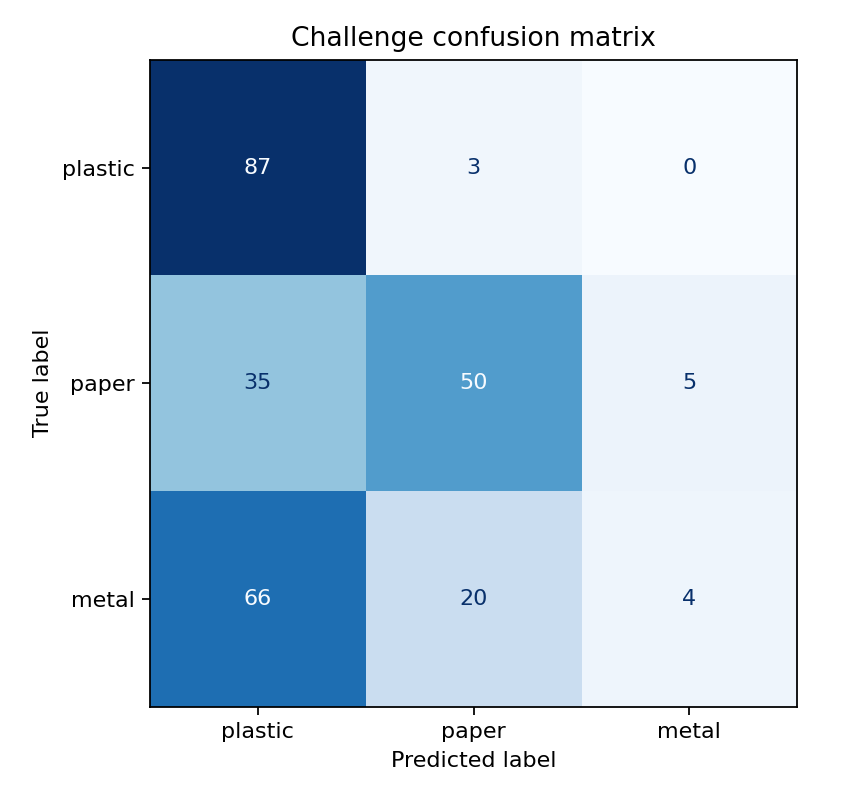

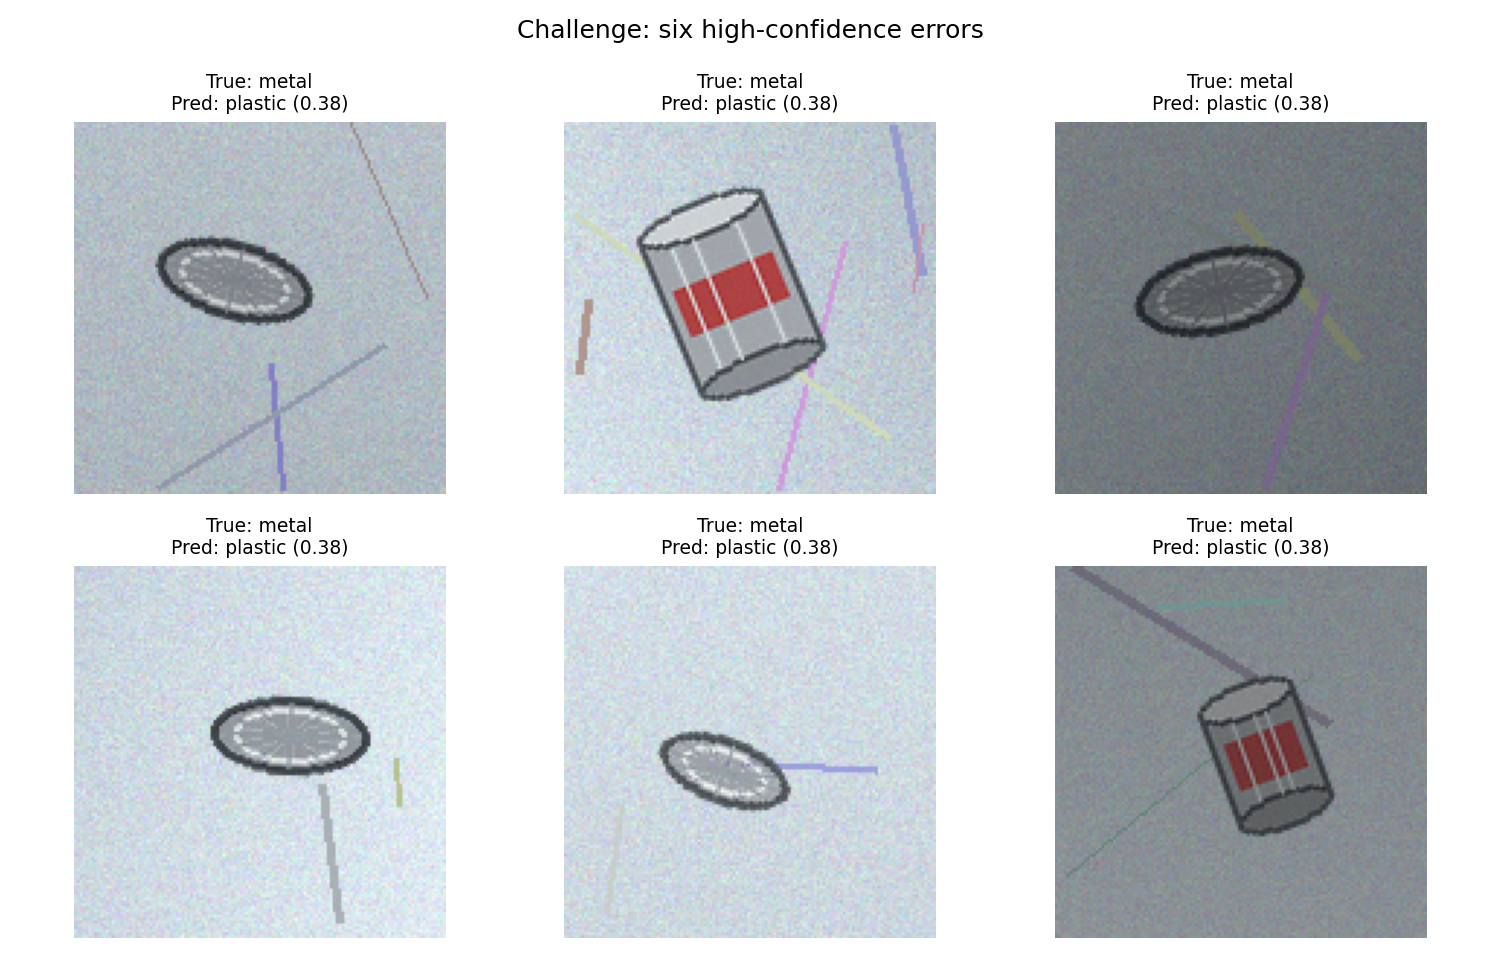

In [7]:
challenge_metrics=metrics_from_predictions(challenge_pred)
print('Challenge seconds:',round(challenge_seconds,2)); print('Accuracy:',round(challenge_metrics['accuracy'],4)); print('Macro-F1:',round(challenge_metrics['macro_f1'],4)); display(challenge_metrics['per_class'].round(3))
save_learning_curves(challenge_history,EVIDENCE/'challenge_loss_curves.png','Challenge loss curves'); save_confusion(challenge_pred,EVIDENCE/'challenge_confusion_matrix.png','Challenge confusion matrix'); challenge_failures=save_failure_grid(challenge_pred,RES,EVIDENCE/'challenge_failures.png',6,'Challenge: six high-confidence errors')
challenge_pred.to_csv(EVIDENCE/'challenge_predictions.csv',index=False); challenge_history.to_csv(EVIDENCE/'challenge_history.csv',index=False)
comparison=pd.DataFrame([
 {'experiment':'baseline','accuracy':baseline_metrics['accuracy'],'macro_f1':baseline_metrics['macro_f1'],'seconds':baseline_seconds},
 {'experiment':'controlled_intervention','accuracy':challenge_metrics['accuracy'],'macro_f1':challenge_metrics['macro_f1'],'seconds':challenge_seconds},
]); display(comparison.round(4)); comparison.to_csv(EVIDENCE/'baseline_vs_challenge.csv',index=False)
display(Image.open(EVIDENCE/'challenge_confusion_matrix.png')); display(Image.open(EVIDENCE/'challenge_failures.png'))

### GROUP ANSWERS - Controlled Experiment

**Required diagnostic:** Compare the train-validation gap and validation macro-F1. Did regularisation help without obvious underfitting?

1. **Was the hypothesis supported, partly supported, or not supported? Quote numerical evidence.** YOUR ANSWER  
2. **What improved?** YOUR ANSWER  
3. **What became worse or remained weak?** YOUR ANSWER  
4. **Why is this a controlled comparison?** YOUR ANSWER  
5. **What uncertainty remains after one run?** YOUR ANSWER

# Part F - Transfer Learning
The cached ResNet18 was **pretrained on a separate six-class source task** (`bottle`, `cup`, `sheet`, `carton`, `can`, `cap`). The assignment target task merges those subtypes into `plastic`, `paper`, and `metal`.

This lets you directly explain what transfer learning means: the backbone begins with parameters learned on a related source task rather than random initialization.

In [9]:
transfer_train,transfer_val,_,_=make_loaders(RES,TRAIN_MANIFEST,VAL_MANIFEST,size=96,batch_size=64,augment=False,seed=SEED,transfer=True)
transfer_model,source_ckpt=load_source_pretrained_resnet(WEIGHTS,num_target_classes=3,freeze_backbone=True)
print('Source classes:',source_ckpt['source_classes']); print('All parameters:',count_all(transfer_model)); print('Trainable parameters:',count_trainable(transfer_model)); print('New head:',transfer_model.fc)
seed_everything(SEED)
transfer_model,transfer_history,transfer_seconds=train_model(transfer_model,transfer_train,transfer_val,epochs=3,lr=2e-3)
transfer_pred=predict(transfer_model,transfer_val); transfer_metrics=metrics_from_predictions(transfer_pred)
print('Transfer seconds:',round(transfer_seconds,2)); print('Accuracy:',round(transfer_metrics['accuracy'],4)); print('Macro-F1:',round(transfer_metrics['macro_f1'],4)); display(transfer_metrics['per_class'].round(3))
save_learning_curves(transfer_history,EVIDENCE/'transfer_loss_curves.png','Transfer learning loss curves'); save_confusion(transfer_pred,EVIDENCE/'transfer_confusion_matrix.png','Transfer learning confusion matrix'); save_failure_grid(transfer_pred,RES,EVIDENCE/'transfer_failures.png',6,'Transfer model: six high-confidence errors')
transfer_pred.to_csv(EVIDENCE/'transfer_predictions.csv',index=False); transfer_history.to_csv(EVIDENCE/'transfer_history.csv',index=False)

Source classes: ['bottle', 'can', 'cap', 'carton', 'cup', 'sheet']
All parameters: 11178051
Trainable parameters: 1539
New head: Linear(in_features=512, out_features=3, bias=True)
Transfer seconds: 12.97
Accuracy: 0.8037
Macro-F1: 0.8072


,class,precision,recall,f1,support
0,plastic,0.984,0.700,0.818,90
1,paper,0.878,0.800,0.837,90
2,metal,0.661,0.911,0.766,90


### GROUP ANSWERS - Transfer Learning

1. **What was transferred?** YOUR ANSWER  
2. **What is the backbone?** YOUR ANSWER  
3. **What is the task-specific head?** YOUR ANSWER  
4. **Does freezing remove the backbone from the forward pass? Explain.** YOUR ANSWER  
5. **Why is normalization used in the transfer pipeline?** YOUR ANSWER  
6. **Did transfer learning improve this target task under the fixed validation protocol? Quote evidence and mention one remaining failure.** YOUR ANSWER

# Part G - Final Evidence Lock
Run the next cell **before leaving the laboratory**. It saves a comparison CSV and creates the ZIP that must be submitted with the notebook.

In [10]:
summary_rows=[
 {'experiment':'baseline_cnn','trainable_params':count_trainable(baseline_model),'key_change':'baseline','accuracy':baseline_metrics['accuracy'],'macro_f1':baseline_metrics['macro_f1'],'seconds':baseline_seconds},
 {'experiment':'controlled_intervention','trainable_params':count_trainable(challenge_model),'key_change':GROUP_NAME,'accuracy':challenge_metrics['accuracy'],'macro_f1':challenge_metrics['macro_f1'],'seconds':challenge_seconds},
 {'experiment':'transfer_resnet18_head','trainable_params':count_trainable(transfer_model),'key_change':'cached source-pretrained backbone; new frozen-backbone head','accuracy':transfer_metrics['accuracy'],'macro_f1':transfer_metrics['macro_f1'],'seconds':transfer_seconds},
]
save_experiment_summary(EVIDENCE,summary_rows)
summary=pd.DataFrame(summary_rows); display(summary.round(4))
zip_path=zip_evidence(EVIDENCE,PACK/f'Group_{GROUP_NUMBER}_Evidence.zip')
print('Evidence ZIP:',zip_path)
print('Submit this notebook and the evidence ZIP before leaving class.')

,experiment,trainable_params,key_change,accuracy,macro_f1,seconds
0,baseline_cnn,23779,baseline,0.5741,0.5215,32.1434
1,controlled_intervention,23779,Weight Decay Regularisation,0.5222,0.4401,25.9684
2,transfer_resnet18_head,1539,cached source-pretrained backbone; new frozen-...,0.8037,0.8072,12.9746


Evidence ZIP: C:\Users\chari\Desktop\Week 1- 4 Prac group assignment\Week 1- 4 Prac group assignment\Group_4_Evidence.zip
Submit this notebook and the evidence ZIP before leaving class.


## Final group conclusion

**Which approach would your group continue developing and why?** YOUR ANSWER  

**Three limitations of this in-class experiment:**  
1. YOUR ANSWER  
2. YOUR ANSWER  
3. YOUR ANSWER  

**One specific next experiment justified by the observed failures:** YOUR ANSWER